# Wine Quality Prediction
**Level 2 - Project 2**

**Objective:** Classify wine as Good/Bad using multiple ML models.


In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn --quiet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import *
import warnings; warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
print('✅ Libraries imported!')

✅ Libraries imported!


## Load Dataset

In [3]:
from google.colab import files
import io
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f'Shape: {df.shape}')
df.head()

Saving WineQT.csv to WineQT.csv
Shape: (1143, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## EDA

In [4]:
df.info()
print(f'Missing: {df.isnull().sum().sum()}')
print(f'\nQuality distribution:')
print(df['quality'].value_counts().sort_index())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB
Missing: 0

Quality distribution:
quality
3      6
4     33
5    483
6    4

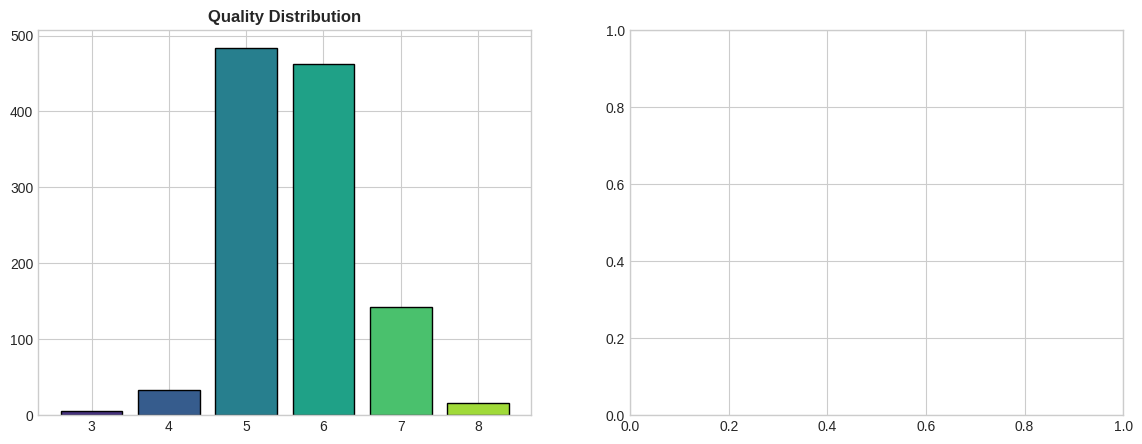

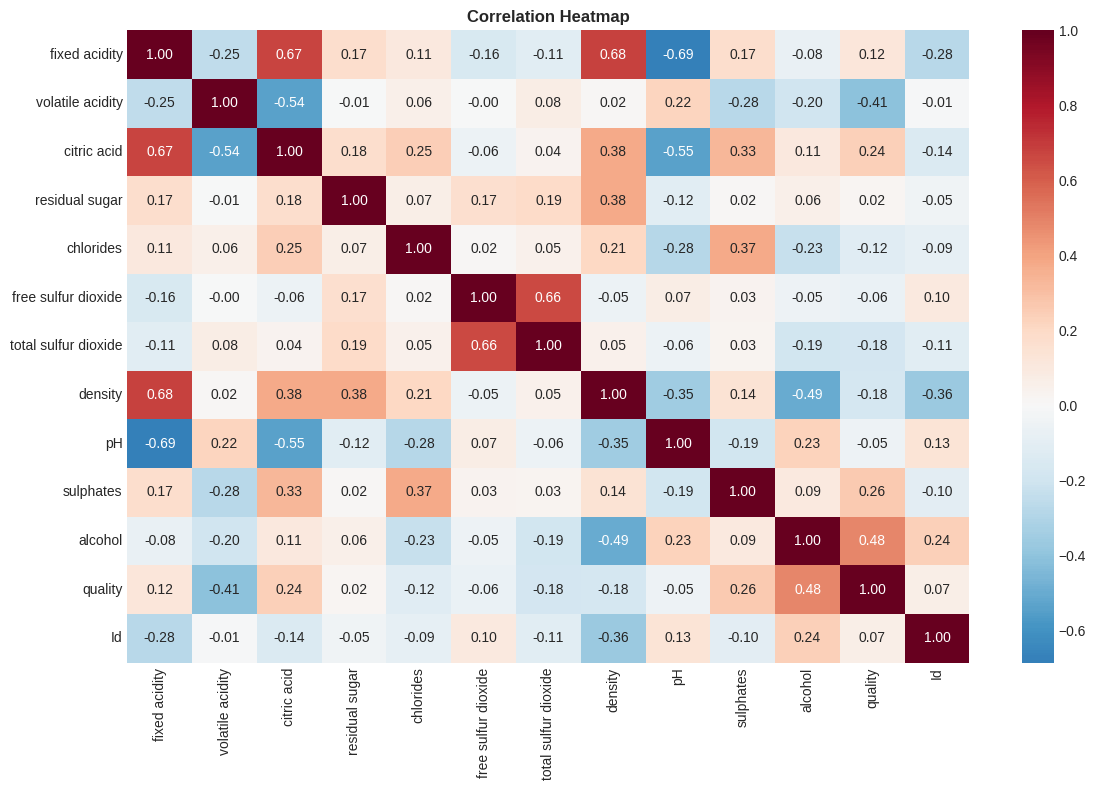

In [5]:
# Quality distribution
fig,axes=plt.subplots(1,2,figsize=(14,5))
q=df['quality'].value_counts().sort_index()
axes[0].bar(q.index,q.values,color=sns.color_palette('viridis',len(q)),edgecolor='black')
axes[0].set_title('Quality Distribution',fontweight='bold')
# Correlation
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap='RdBu_r',center=0,fmt='.2f')
plt.title('Correlation Heatmap',fontweight='bold')
plt.tight_layout(); plt.show()

## Preprocessing

In [7]:
# Binary label: quality >= 7 = Good
df['label'] = (df['quality'] >= 7).astype(int)
print(f'Good: {df["label"].sum()}, Not Good: {(df["label"]==0).sum()}')

drop_cols = ['quality','label']
if 'Id' in df.columns: drop_cols.append('Id')
X = df.drop(columns=drop_cols)
y = df['label']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
scaler=StandardScaler()
X_train_s=scaler.fit_transform(X_train)
X_test_s=scaler.transform(X_test)
print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')

Good: 159, Not Good: 984
Train: 914, Test: 229


## Model Training

In [8]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000,random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100,random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100,random_state=42),
    'SVM': SVC(probability=True,random_state=42)
}
results = {}
for name,model in models.items():
    model.fit(X_train_s,y_train)
    yp=model.predict(X_test_s)
    yprob=model.predict_proba(X_test_s)[:,1]
    results[name]={'Accuracy':accuracy_score(y_test,yp),'Precision':precision_score(y_test,yp),
        'Recall':recall_score(y_test,yp),'F1':f1_score(y_test,yp),'AUC':roc_auc_score(y_test,yprob),'yp':yp,'yprob':yprob}
    print(f'{name}: F1={results[name]["F1"]:.4f}, AUC={results[name]["AUC"]:.4f}')

Logistic Regression: F1=0.4151, AUC=0.8418
Random Forest: F1=0.6786, AUC=0.9087
Gradient Boosting: F1=0.6102, AUC=0.8786
SVM: F1=0.5306, AUC=0.8498


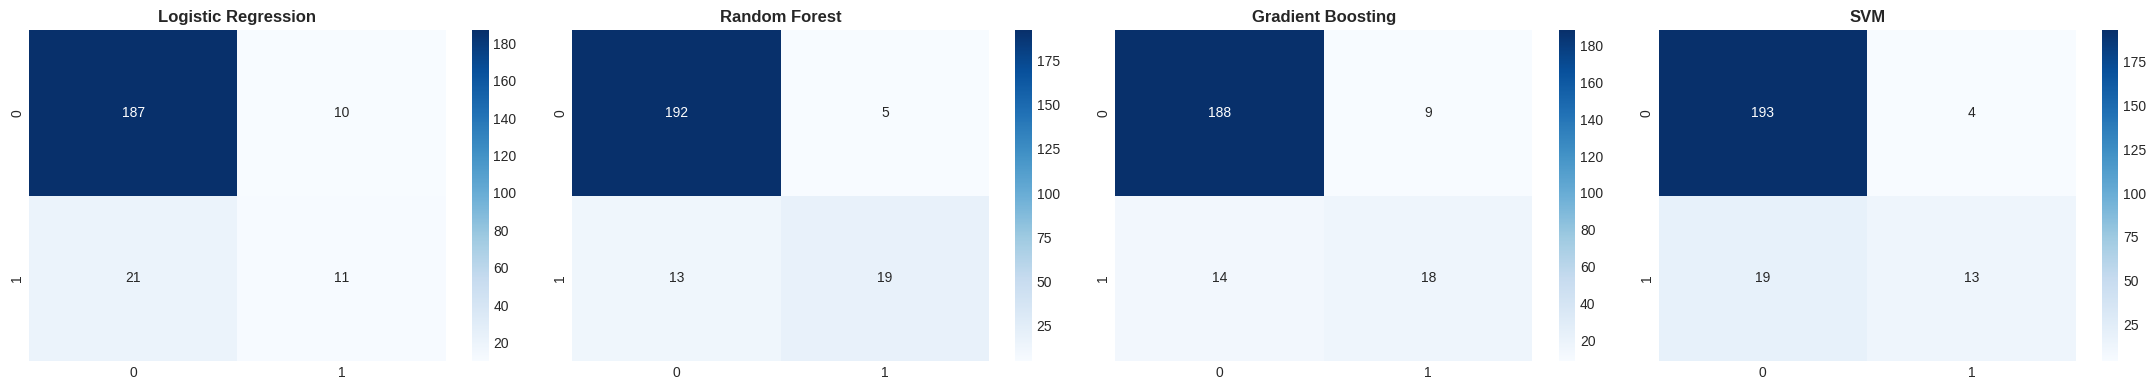

In [9]:
# Confusion matrices
fig,axes=plt.subplots(1,4,figsize=(22,4))
for i,(name,r) in enumerate(results.items()):
    cm=confusion_matrix(y_test,r['yp'])
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=axes[i])
    axes[i].set_title(name,fontweight='bold')
plt.tight_layout(); plt.show()

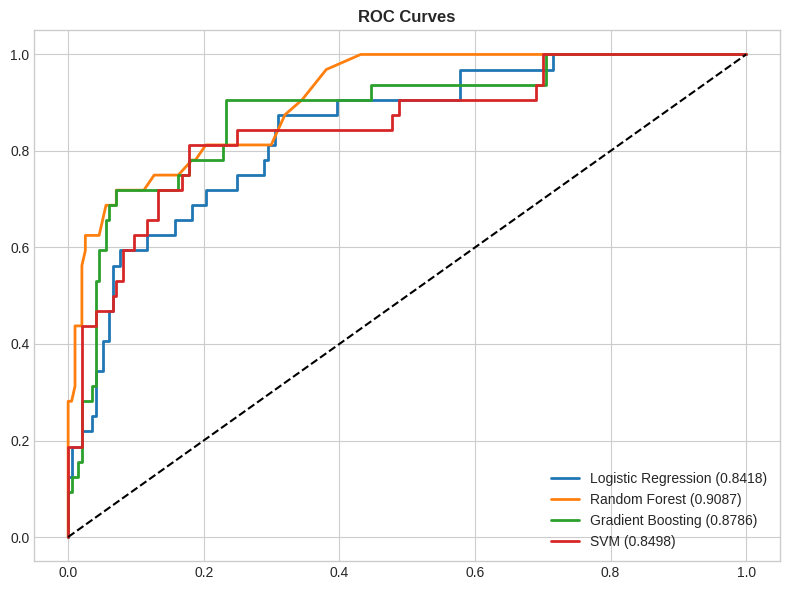

In [10]:
# ROC curves
plt.figure(figsize=(8,6))
for name,r in results.items():
    fpr,tpr,_=roc_curve(y_test,r['yprob'])
    plt.plot(fpr,tpr,lw=2,label=f"{name} ({r['AUC']:.4f})")
plt.plot([0,1],[0,1],'k--')
plt.title('ROC Curves',fontweight='bold'); plt.legend(); plt.tight_layout(); plt.show()

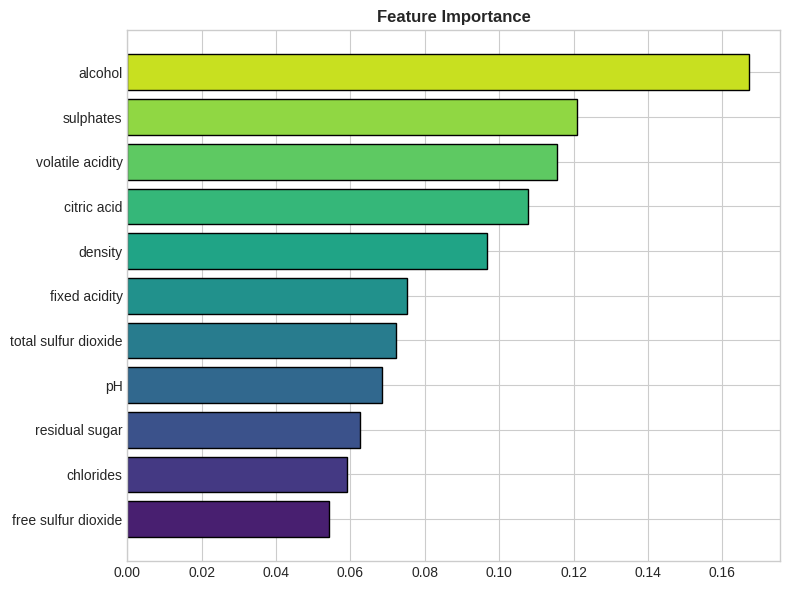

In [11]:
# Feature importance
rf=models['Random Forest']
fi=pd.DataFrame({'Feature':X.columns,'Imp':rf.feature_importances_}).sort_values('Imp')
plt.figure(figsize=(8,6))
plt.barh(fi['Feature'],fi['Imp'],color=sns.color_palette('viridis',len(fi)),edgecolor='black')
plt.title('Feature Importance',fontweight='bold'); plt.tight_layout(); plt.show()

## Summary

In [13]:
comp=pd.DataFrame({n:{k:v for k,v in r.items() if k not in['yp','yprob']} for n,r in results.items()}).T
print(comp)
print(f'\n Best: {comp["F1"].idxmax()}')

                     Accuracy  Precision   Recall        F1       AUC
Logistic Regression  0.864629   0.523810  0.34375  0.415094  0.841846
Random Forest        0.921397   0.791667  0.59375  0.678571  0.908709
Gradient Boosting    0.899563   0.666667  0.56250  0.610169  0.878648
SVM                  0.899563   0.764706  0.40625  0.530612  0.849778

 Best: Random Forest
